### ***Problem Statement:***
- As a Data scientist,  working for a startup investment firm. The firm helps customers make informed decisions about investing in stocks.
- My task is to extract financial data such as historical stock prices and quarterly revenue—from multiple sources using Python libraries and web scraping techniques. 
- Then visualize this data in a dashboard to identify patterns and trends.

In [1]:
import pandas as pd
import numpy as np
import warnings
import yfinance as yf
import matplotlib as plt
import plotly
from bs4 import BeautifulSoup
import requests
import lxml
from io import StringIO

In [2]:
# Ignore all warnings
warnings.filterwarnings('ignore',category=FutureWarning)

Question 1: Use yfinance to Extract Stock Data

Reset the index, save, and display the first five rows of the tesla_data dataframe using the head function. Upload a screenshot of the results and code from the beginning of Question 1 to the results below.

In [173]:
Tesla = yf.Ticker('TSLA')

In [174]:
Tesla

yfinance.Ticker object <TSLA>

In [172]:
#Tesla.info

In [9]:
TSLA_dict = {}

for k, v in st_name.info.items():
    TSLA_dict[k] = v 
print('Successfully created')

Successfully created


In [10]:
TSLA_dict['country']

'United States'

In [175]:
TSLA_Stock_Data = Tesla.history(period='max')

In [177]:
TSLA_Stock_Data.head()

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2010-06-29 00:00:00-04:00,1.266667,1.666667,1.169333,1.592667,281494500,0.0,0.0
2010-06-30 00:00:00-04:00,1.719333,2.028000,1.553333,1.588667,257806500,0.0,0.0
2010-07-01 00:00:00-04:00,1.666667,1.728000,1.351333,1.464000,123282000,0.0,0.0
2010-07-02 00:00:00-04:00,1.533333,1.540000,1.247333,1.280000,77097000,0.0,0.0
2010-07-06 00:00:00-04:00,1.333333,1.333333,1.055333,1.074000,103003500,0.0,0.0


In [13]:
type(TSLA_Stock_Data)

pandas.core.frame.DataFrame

In [14]:
TSLA_Stock_Data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 4042 entries, 2010-06-29 00:00:00-04:00 to 2026-07-24 00:00:00-04:00
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Open          4042 non-null   float64
 1   High          4042 non-null   float64
 2   Low           4042 non-null   float64
 3   Close         4042 non-null   float64
 4   Volume        4042 non-null   int64  
 5   Dividends     4042 non-null   float64
 6   Stock Splits  4042 non-null   float64
dtypes: float64(6), int64(1)
memory usage: 252.6 KB


In [15]:
TSLA_Stock_Data.index

DatetimeIndex(['2010-06-29 00:00:00-04:00', '2010-06-30 00:00:00-04:00',
               '2010-07-01 00:00:00-04:00', '2010-07-02 00:00:00-04:00',
               '2010-07-06 00:00:00-04:00', '2010-07-07 00:00:00-04:00',
               '2010-07-08 00:00:00-04:00', '2010-07-09 00:00:00-04:00',
               '2010-07-12 00:00:00-04:00', '2010-07-13 00:00:00-04:00',
               ...
               '2026-07-13 00:00:00-04:00', '2026-07-14 00:00:00-04:00',
               '2026-07-15 00:00:00-04:00', '2026-07-16 00:00:00-04:00',
               '2026-07-17 00:00:00-04:00', '2026-07-20 00:00:00-04:00',
               '2026-07-21 00:00:00-04:00', '2026-07-22 00:00:00-04:00',
               '2026-07-23 00:00:00-04:00', '2026-07-24 00:00:00-04:00'],
              dtype='datetime64[ns, America/New_York]', name='Date', length=4042, freq=None)

In [16]:
TSLA_Stock_Data.reset_index(inplace=True)

In [17]:
TSLA_Stock_Data.index

RangeIndex(start=0, stop=4042, step=1)

In [18]:
TSLA_Stock_Data.index = TSLA_Stock_Data.index +1

In [19]:
TSLA_Stock_Data.index

RangeIndex(start=1, stop=4043, step=1)

In [20]:
TSLA_Stock_Data.

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
1,2010-06-29 00:00:00-04:00,1.266667,1.666667,1.169333,1.592667,281494500,0.0,0.0
2,2010-06-30 00:00:00-04:00,1.719333,2.028000,1.553333,1.588667,257806500,0.0,0.0
3,2010-07-01 00:00:00-04:00,1.666667,1.728000,1.351333,1.464000,123282000,0.0,0.0
4,2010-07-02 00:00:00-04:00,1.533333,1.540000,1.247333,1.280000,77097000,0.0,0.0
5,2010-07-06 00:00:00-04:00,1.333333,1.333333,1.055333,1.074000,103003500,0.0,0.0


In [153]:
tesla_data = TSLA_Stock_Data.loc[:,['Date','Close']]

In [154]:
tesla_data.head()

,Date,Close
1,2010-06-29 00:00:00-04:00,1.592667
2,2010-06-30 00:00:00-04:00,1.588667
3,2010-07-01 00:00:00-04:00,1.464000
4,2010-07-02 00:00:00-04:00,1.280000
5,2010-07-06 00:00:00-04:00,1.074000


In [21]:
url = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-PY0220EN-SkillsNetwork/labs/project/revenue.htm'

Html_data =  requests.get(url)

soup = BeautifulSoup(Html_data.text,'lxml')



In [22]:
tesla_revenue = pd.read_html(StringIO(str(soup)))

In [23]:
df_tesla_revenue = tesla_revenue[1]

In [24]:
df_tesla_revenue

,Tesla Quarterly Revenue (Millions of US $),Tesla Quarterly Revenue (Millions of US $).1
0,2022-09-30,"$21,454"
1,2022-06-30,"$16,934"
2,2022-03-31,"$18,756"
3,2021-12-31,"$17,719"
4,2021-09-30,"$13,757"
5,2021-06-30,"$11,958"
6,2021-03-31,"$10,389"
7,2020-12-31,"$10,744"
8,2020-09-30,"$8,771"
9,2020-06-30,"$6,036"


In [33]:
df_tesla_revenue.columns

Index(['Date', 'Revenue Q (Millions of US $)'], dtype='object')

In [34]:
df_tesla_revenue.columns = ['Date', 'Revenue Q (Millions of US $)']

In [35]:
df_tesla_revenue.columns

Index(['Date', 'Revenue Q (Millions of US $)'], dtype='object')

In [36]:
df_tesla_revenue.head()

,Date,Revenue Q (Millions of US $)
1,2022-09-30,"$21,454"
2,2022-06-30,"$16,934"
3,2022-03-31,"$18,756"
4,2021-12-31,"$17,719"
5,2021-09-30,"$13,757"


In [37]:
df_tesla_revenue.index = df_tesla_revenue.index +1

In [38]:
df_tesla_revenue.head()

,Date,Revenue Q (Millions of US $)
2,2022-09-30,"$21,454"
3,2022-06-30,"$16,934"
4,2022-03-31,"$18,756"
5,2021-12-31,"$17,719"
6,2021-09-30,"$13,757"


In [39]:
df_tesla_revenue

,Date,Revenue Q (Millions of US $)
2,2022-09-30,"$21,454"
3,2022-06-30,"$16,934"
4,2022-03-31,"$18,756"
5,2021-12-31,"$17,719"
6,2021-09-30,"$13,757"
7,2021-06-30,"$11,958"
8,2021-03-31,"$10,389"
9,2020-12-31,"$10,744"
10,2020-09-30,"$8,771"
11,2020-06-30,"$6,036"


In [40]:
df_tesla_revenue['Revenue Q (Millions of US $)'] = df_tesla_revenue['Revenue Q (Millions of US $)'].str.replace('$','').str.replace(',','')

In [45]:
df_tesla_revenue.tail()

,Date,Revenue Q (Millions of US $)
51,2010-06-30,28.0
52,2010-03-31,21.0
53,2009-12-31,NaN
54,2009-09-30,46.0
55,2009-06-30,27.0


In [46]:
df_tesla_revenue.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54 entries, 2 to 55
Data columns (total 2 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   Date                          54 non-null     datetime64[ns]
 1   Revenue Q (Millions of US $)  53 non-null     float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 996.0 bytes


In [51]:
def convert_datatype():
    df_tesla_revenue['Date'] =  df_tesla_revenue['Date'].astype('datetime64[ns]')
    df_tesla_revenue['Revenue Q (Millions of US $)'] =   df_tesla_revenue['Revenue Q (Millions of US $)'].astype('float')

In [52]:
df_tesla_revenue.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54 entries, 2 to 55
Data columns (total 2 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   Date                          54 non-null     datetime64[ns]
 1   Revenue Q (Millions of US $)  53 non-null     float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 996.0 bytes


In [53]:
df_tesla_revenue.tail()

,Date,Revenue Q (Millions of US $)
51,2010-06-30,28.0
52,2010-03-31,21.0
53,2009-12-31,NaN
54,2009-09-30,46.0
55,2009-06-30,27.0


In [56]:
df_tesla_revenue.dropna(inplace=True)

In [57]:
df_tesla_revenue.tail()

,Date,Revenue Q (Millions of US $)
50,2010-09-30,31.0
51,2010-06-30,28.0
52,2010-03-31,21.0
54,2009-09-30,46.0
55,2009-06-30,27.0


In [155]:
tesla_revenue = df_tesla_revenue

In [156]:
tesla_revenue.head()

,Date,Revenue Q (Millions of US $)
2,2022-09-30,21454.0
3,2022-06-30,16934.0
4,2022-03-31,18756.0
5,2021-12-31,17719.0
6,2021-09-30,13757.0


In [157]:
tesla_revenue.columns = ['Date', 'Revenue']

In [158]:
tesla_revenue.columns

Index(['Date', 'Revenue'], dtype='object')

# Question 3: Use yfinance to Extract Stock Data¶

#### Using the Ticker function enter the ticker symbol of the stock we want to extract data on to create a ticker object. The stock is GameStop and its ticker symbol is GME.

In [ ]:
### Extracting gme_data (GME)

In [58]:
st_name1 = yf.Ticker('GME')

In [59]:
st_name1

yfinance.Ticker object <GME>

#### Using the ticker object and the function history extract stock information and save it in a dataframe named gme_data. Set the period parameter to "max" so we get information for the maximum amount of time.

####### ***Storing in DataFrame***

In [60]:
GME_Stock_Data = st_name1.history(period='max')

In [62]:
GME_Stock_Data

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2002-02-13 00:00:00-05:00,1.620128,1.693350,1.603296,1.691666,76216000,0.0,0.0
2002-02-14 00:00:00-05:00,1.712707,1.716073,1.670626,1.683250,11021600,0.0,0.0
2002-02-15 00:00:00-05:00,1.683251,1.687459,1.658002,1.674834,8389600,0.0,0.0
2002-02-19 00:00:00-05:00,1.666418,1.666418,1.578048,1.607504,7410400,0.0,0.0
2002-02-20 00:00:00-05:00,1.615921,1.662210,1.603296,1.662210,6892800,0.0,0.0
...,...,...,...,...,...,...,...
2026-07-20 00:00:00-04:00,21.889999,21.980000,21.670000,21.760000,3923300,0.0,0.0
2026-07-21 00:00:00-04:00,21.780001,21.900000,21.580000,21.790001,2916200,0.0,0.0
2026-07-22 00:00:00-04:00,21.799999,21.879999,21.540001,21.600000,3171200,0.0,0.0


#### Reset the index using the reset_index(inplace=True) function on the gme_data DataFrame and display the first five rows of the gme_data dataframe using the head function. Take a screenshot of the results and code from the beginning of Question 3 to the results below.

In [63]:
GME_Stock_Data.reset_index(inplace=True)

In [64]:
GME_Stock_Data

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,2002-02-13 00:00:00-05:00,1.620128,1.693350,1.603296,1.691666,76216000,0.0,0.0
1,2002-02-14 00:00:00-05:00,1.712707,1.716073,1.670626,1.683250,11021600,0.0,0.0
2,2002-02-15 00:00:00-05:00,1.683251,1.687459,1.658002,1.674834,8389600,0.0,0.0
3,2002-02-19 00:00:00-05:00,1.666418,1.666418,1.578048,1.607504,7410400,0.0,0.0
4,2002-02-20 00:00:00-05:00,1.615921,1.662210,1.603296,1.662210,6892800,0.0,0.0
...,...,...,...,...,...,...,...,...
6145,2026-07-20 00:00:00-04:00,21.889999,21.980000,21.670000,21.760000,3923300,0.0,0.0
6146,2026-07-21 00:00:00-04:00,21.780001,21.900000,21.580000,21.790001,2916200,0.0,0.0
6147,2026-07-22 00:00:00-04:00,21.799999,21.879999,21.540001,21.600000,3171200,0.0,0.0
6148,2026-07-23 00:00:00-04:00,21.480000,21.540001,21.209999,21.350000,3683600,0.0,0.0


##### Reset index value from 0 to 1

In [68]:
GME_Stock_Data.index = GME_Stock_Data.index +1

In [69]:
GME_Stock_Data

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
2,2002-02-13 00:00:00-05:00,1.620128,1.693350,1.603296,1.691666,76216000,0.0,0.0
3,2002-02-14 00:00:00-05:00,1.712707,1.716073,1.670626,1.683250,11021600,0.0,0.0
4,2002-02-15 00:00:00-05:00,1.683251,1.687459,1.658002,1.674834,8389600,0.0,0.0
5,2002-02-19 00:00:00-05:00,1.666418,1.666418,1.578048,1.607504,7410400,0.0,0.0
6,2002-02-20 00:00:00-05:00,1.615921,1.662210,1.603296,1.662210,6892800,0.0,0.0
...,...,...,...,...,...,...,...,...
6147,2026-07-20 00:00:00-04:00,21.889999,21.980000,21.670000,21.760000,3923300,0.0,0.0
6148,2026-07-21 00:00:00-04:00,21.780001,21.900000,21.580000,21.790001,2916200,0.0,0.0
6149,2026-07-22 00:00:00-04:00,21.799999,21.879999,21.540001,21.600000,3171200,0.0,0.0
6150,2026-07-23 00:00:00-04:00,21.480000,21.540001,21.209999,21.350000,3683600,0.0,0.0


# Question 4: Use Webscraping to Extract GME Revenue Data

Use the requests library to download the webpage https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-PY0220EN-SkillsNetwork/labs/project/stock.html. Save the text of the response as a variable named html_data_2

In [71]:
URL = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-PY0220EN-SkillsNetwork/labs/project/stock.html'
html_data_2 = requests.get(URL)
html_data_2.status_code

200

Parse the html data using beautiful_soup using parser i.e html5lib or html.parser.

In [73]:
soup =  BeautifulSoup(html_data_2.text, 'lxml')
soup.prettify()

'<!DOCTYPE html>\n<!-- saved from url=(0105)https://web.archive.org/web/20200814131437/https://www.macrotrends.net/stocks/charts/GME/gamestop/revenue -->\n<html class="js flexbox canvas canvastext webgl no-touch geolocation postmessage websqldatabase indexeddb hashchange history draganddrop websockets rgba hsla multiplebgs backgroundsize borderimage borderradius boxshadow textshadow opacity cssanimations csscolumns cssgradients cssreflections csstransforms csstransforms3d csstransitions fontface generatedcontent video audio localstorage sessionstorage webworkers no-applicationcache svg inlinesvg smil svgclippaths" style="">\n <!--<![endif]-->\n <head>\n  <meta content="text/html; charset=utf-8" http-equiv="Content-Type"/>\n  <script async="" src="./GameStop Revenue 2006-2020 _ GME _ MacroTrends_files/analytics.js.download" type="text/javascript">\n  </script>\n  <script async="" src="./GameStop Revenue 2006-2020 _ GME _ MacroTrends_files/gpt.js.download" type="text/javascript">\n  </sc

Using BeautifulSoup or the read_html function extract the table with GameStop Revenue and store it into a dataframe named gme_revenue. The dataframe should have columns Date and Revenue. Make sure the comma and dollar sign is removed from the Revenue column.

In [76]:
table_row = soup.select('tbody tr')

In [108]:
table_row[16]

<tr>
<td style="text-align:center">2020-04-30</td>
<td style="text-align:center">$1,021</td>
</tr>

In [95]:
col =soup.select('td')

In [102]:
col[61].text

'$1,959'

In [98]:
len(col)

197

In [99]:
col[50]

<td style="text-align:center">2018-01-31</td>

In [109]:
data  =  []

for tr in table_row[16:78]:
    cols = tr.select('td')
    Date = cols[0].text.strip()
    Price = cols[1].text.strip()
    data.append([Date,Price])
print ('Successfully')

Successfully


In [110]:
data

[['2020-04-30', '$1,021'],
 ['2020-01-31', '$2,194'],
 ['2019-10-31', '$1,439'],
 ['2019-07-31', '$1,286'],
 ['2019-04-30', '$1,548'],
 ['2019-01-31', '$3,063'],
 ['2018-10-31', '$1,935'],
 ['2018-07-31', '$1,501'],
 ['2018-04-30', '$1,786'],
 ['2018-01-31', '$2,825'],
 ['2017-10-31', '$1,989'],
 ['2017-07-31', '$1,688'],
 ['2017-04-30', '$2,046'],
 ['2017-01-31', '$2,403'],
 ['2016-10-31', '$1,959'],
 ['2016-07-31', '$1,632'],
 ['2016-04-30', '$1,972'],
 ['2016-01-31', '$3,525'],
 ['2015-10-31', '$2,016'],
 ['2015-07-31', '$1,762'],
 ['2015-04-30', '$2,061'],
 ['2015-01-31', '$3,476'],
 ['2014-10-31', '$2,092'],
 ['2014-07-31', '$1,731'],
 ['2014-04-30', '$1,996'],
 ['2014-01-31', '$3,684'],
 ['2013-10-31', '$2,107'],
 ['2013-07-31', '$1,384'],
 ['2013-04-30', '$1,865'],
 ['2013-01-31', '$3,562'],
 ['2012-10-31', '$1,773'],
 ['2012-07-31', '$1,550'],
 ['2012-04-30', '$2,002'],
 ['2012-01-31', '$3,579'],
 ['2011-10-31', '$1,947'],
 ['2011-07-31', '$1,744'],
 ['2011-04-30', '$2,281'],
 

In [112]:
df_gme_revenue = pd.DataFrame(data,columns=['Date','Price'])

In [113]:
df_gme_revenue.head()

,Date,Price
0,2020-04-30,"$1,021"
1,2020-01-31,"$2,194"
2,2019-10-31,"$1,439"
3,2019-07-31,"$1,286"
4,2019-04-30,"$1,548"


In [114]:
df_gme_revenue.index = df_gme_revenue.index +1

In [115]:
df_gme_revenue.head()

,Date,Price
1,2020-04-30,"$1,021"
2,2020-01-31,"$2,194"
3,2019-10-31,"$1,439"
4,2019-07-31,"$1,286"
5,2019-04-30,"$1,548"


###### Remove the comma and dollar sign, an null or empty strings from the Revenue column.

In [116]:
df_gme_revenue['Price'] =  df_gme_revenue['Price'].str.replace(',','').str.replace('$','')

In [117]:
df_gme_revenue.head()

,Date,Price
1,2020-04-30,1021
2,2020-01-31,2194
3,2019-10-31,1439
4,2019-07-31,1286
5,2019-04-30,1548


In [119]:
df_gme_revenue.isna().sum()

Date     0
Price    0
dtype: int64

In [122]:
df_gme_revenue.loc[31:65]

,Date,Price
31,2012-10-31,1773
32,2012-07-31,1550
33,2012-04-30,2002
34,2012-01-31,3579
35,2011-10-31,1947
36,2011-07-31,1744
37,2011-04-30,2281
38,2011-01-31,3693
39,2010-10-31,1899
40,2010-07-31,1799


In [123]:
df_gme_revenue.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62 entries, 1 to 62
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Date    62 non-null     object
 1   Price   62 non-null     object
dtypes: object(2)
memory usage: 1.1+ KB


In [125]:
## changing datatypes

def convert_datatypes_Gme():
     df_gme_revenue['Date'] = pd.to_datetime( df_gme_revenue['Date'])
     df_gme_revenue['Price'] =  df_gme_revenue['Price'].astype('float')

In [126]:
convert_datatypes_Gme()

In [127]:
df_gme_revenue.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62 entries, 1 to 62
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    62 non-null     datetime64[ns]
 1   Price   62 non-null     float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 1.1 KB


#### Display the last five rows of the gme_revenue dataframe using the tail function. Take a screenshot of the results.

In [130]:
# first 5 rows
df_gme_revenue.head()

,Date,Price
1,2020-04-30,1021.0
2,2020-01-31,2194.0
3,2019-10-31,1439.0
4,2019-07-31,1286.0
5,2019-04-30,1548.0


In [131]:
# Last 5 rows

df_gme_revenue.tail()

,Date,Price
58,2006-01-31,1667.0
59,2005-10-31,534.0
60,2005-07-31,416.0
61,2005-04-30,475.0
62,2005-01-31,709.0


In [161]:
gme_revenue.columns = ["Date", "Revenue"]

### Define Graphing Function
In this section, we define the function make_graph. You don't have to know how the function works, you should only care about the inputs. It takes a dataframe with stock data (dataframe must contain Date and Close columns), a dataframe with revenue data (dataframe must contain Date and Revenue columns), and the name of the stock.

In [162]:
# The make_graph function has been modified to use Matplotlib for static graphs. Earlier, it used Plotly to generate interactive dashboards, which caused issues when uploading the notebook in the MARK assignment submission.



import matplotlib.pyplot as plt

def make_graph(stock_data, revenue_data, stock):
    stock_data_specific = stock_data[stock_data.Date <= '2021-06-14']
    revenue_data_specific = revenue_data[revenue_data.Date <= '2021-04-30']
    
    fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
    
    # Stock price
    axes[0].plot(pd.to_datetime(stock_data_specific.Date), stock_data_specific.Close.astype("float"), label="Share Price", color="blue")
    axes[0].set_ylabel("Price ($US)")
    axes[0].set_title(f"{stock} - Historical Share Price")
    
    # Revenue
    axes[1].plot(pd.to_datetime(revenue_data_specific.Date), revenue_data_specific.Revenue.astype("float"), label="Revenue", color="green")
    axes[1].set_ylabel("Revenue ($US Millions)")
    axes[1].set_xlabel("Date")
    axes[1].set_title(f"{stock} - Historical Revenue")
    
    plt.tight_layout()
    plt.show()

In [163]:
GME_Stock_Data

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
2,2002-02-13 00:00:00-05:00,1.620128,1.693350,1.603296,1.691666,76216000,0.0,0.0
3,2002-02-14 00:00:00-05:00,1.712707,1.716073,1.670626,1.683250,11021600,0.0,0.0
4,2002-02-15 00:00:00-05:00,1.683251,1.687459,1.658002,1.674834,8389600,0.0,0.0
5,2002-02-19 00:00:00-05:00,1.666418,1.666418,1.578048,1.607504,7410400,0.0,0.0
6,2002-02-20 00:00:00-05:00,1.615921,1.662210,1.603296,1.662210,6892800,0.0,0.0
...,...,...,...,...,...,...,...,...
6147,2026-07-20 00:00:00-04:00,21.889999,21.980000,21.670000,21.760000,3923300,0.0,0.0
6148,2026-07-21 00:00:00-04:00,21.780001,21.900000,21.580000,21.790001,2916200,0.0,0.0
6149,2026-07-22 00:00:00-04:00,21.799999,21.879999,21.540001,21.600000,3171200,0.0,0.0
6150,2026-07-23 00:00:00-04:00,21.480000,21.540001,21.209999,21.350000,3683600,0.0,0.0


In [164]:
gme_data =  GME_Stock_Data.loc[:,['Date','Close']]

In [165]:
gme_data

,Date,Close
2,2002-02-13 00:00:00-05:00,1.691666
3,2002-02-14 00:00:00-05:00,1.683250
4,2002-02-15 00:00:00-05:00,1.674834
5,2002-02-19 00:00:00-05:00,1.607504
6,2002-02-20 00:00:00-05:00,1.662210
...,...,...
6147,2026-07-20 00:00:00-04:00,21.760000
6148,2026-07-21 00:00:00-04:00,21.790001
6149,2026-07-22 00:00:00-04:00,21.600000
6150,2026-07-23 00:00:00-04:00,21.350000


In [166]:
gme_revenue = df_gme_revenue

In [167]:
gme_revenue.head(2)

,Date,Revenue
1,2020-04-30,1021.0
2,2020-01-31,2194.0


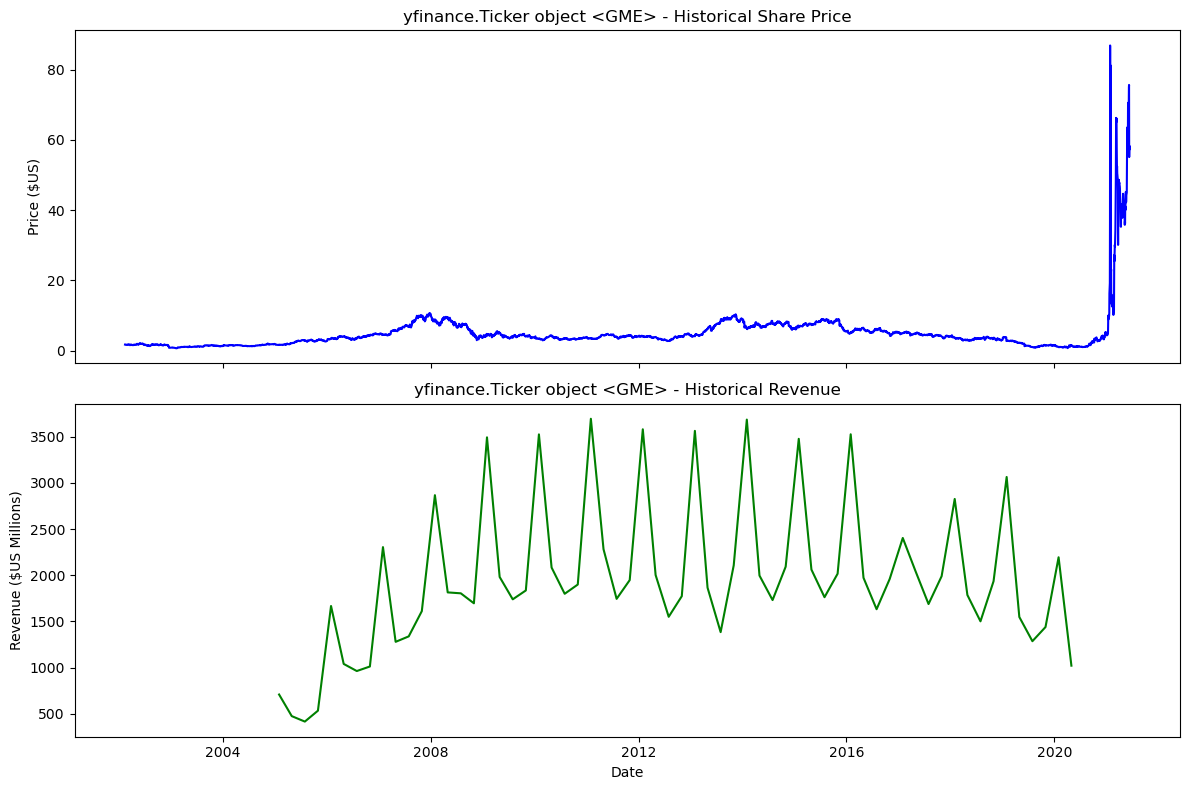

In [168]:
make_graph(gme_data, gme_revenue, st_name1)

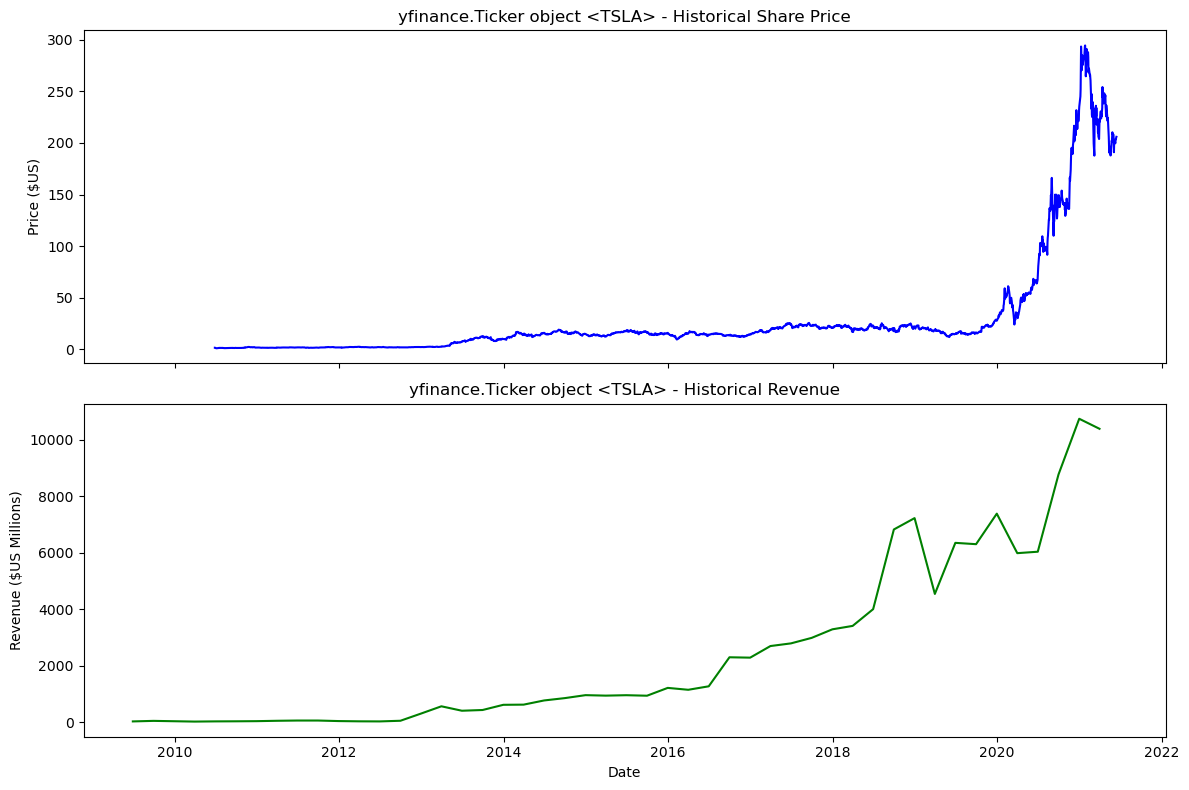

In [169]:
make_graph(tesla_data, tesla_revenue, st_name)

========================End===============================================

In [171]:
gme_data[gme_data['Date'] == '2002-02-13']

,Date,Close
2,2002-02-13 00:00:00-05:00,1.691666
